In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df=pd.read_excel('processed_dataset.xlsx')

In [15]:
features = ['Open_scaled', 'High_scaled', 'Low_scaled', 'Close*_scaled', 'Volume_scaled',
            'ret_1d', 'ma_7', 'ma_30', 'vol_14']  # Use scaled and engineered features
X = df[features]
y = df['Adj Close**_scaled']

In [16]:
# Scale features (optional if already scaled)
scaler = StandardScaler()
X_scaled = X

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (939, 9)
X_test shape: (235, 9)


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
import numpy as np


param_distributions = {

    'kernel': ['linear', 'rbf', 'poly'],

    'C': np.logspace(-3, 3, 7),


    'epsilon': [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],


    'gamma': ['scale', 'auto'] + list(np.logspace(-4, 1, 6)),


    'degree': [2, 3, 4, 5],


    'coef0': [0.0, 0.1, 1.0],
    'shrinking': [True, False],
    'max_iter': [1000, 2000, 5000]
}

print(f"Total possible combinations: ~{3*7*10*8*4*3*2*3:,}")
print("Using RandomizedSearchCV with n_iter=200 for efficient search...")


random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_distributions,
    n_iter=200,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    return_train_score=True
)

# Fit the model
print("\n🚀 Starting hyperparameter search...")
random_search.fit(X_train, y_train)

# Results
best_svr = random_search.best_estimator_
print("\n" + "="*50)
print("🎯 BEST RESULTS")
print("="*50)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV MSE: {-random_search.best_score_:.6f}")

# Test evaluation
y_pred = best_svr.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {test_mse:.6f}")
print(f"Test R²: {test_r2:.4f}")

# Show search statistics
print(f"\n📊 Search Statistics:")
print(f"Total combinations tried: {random_search.n_splits_ * random_search.n_iter}")
print(f"Best CV score rank: {np.argmax(-random_search.cv_results_['mean_test_score']) + 1}")

Total possible combinations: ~120,960
Using RandomizedSearchCV with n_iter=200 for efficient search...

🚀 Starting hyperparameter search...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits

🎯 BEST RESULTS
Best Parameters: {'shrinking': True, 'max_iter': 1000, 'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.1, 'degree': 5, 'coef0': 0.0, 'C': np.float64(1.0)}
Best CV MSE: 0.002078
Test MSE: 0.002291
Test R²: 0.9626

📊 Search Statistics:
Total combinations tried: 1000
Best CV score rank: 25


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py", line 276, in fit
    raise ValueError(
ValueError: The 

In [18]:

y_pred = best_svr.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


baseline_mse = mean_squared_error(y_test, [y_train.mean()] * len(y_test))
print(f"Baseline MSE (mean prediction): {baseline_mse:.4f}")

Mean Squared Error: 0.0023
R² Score: 0.9626
Baseline MSE (mean prediction): 0.0612


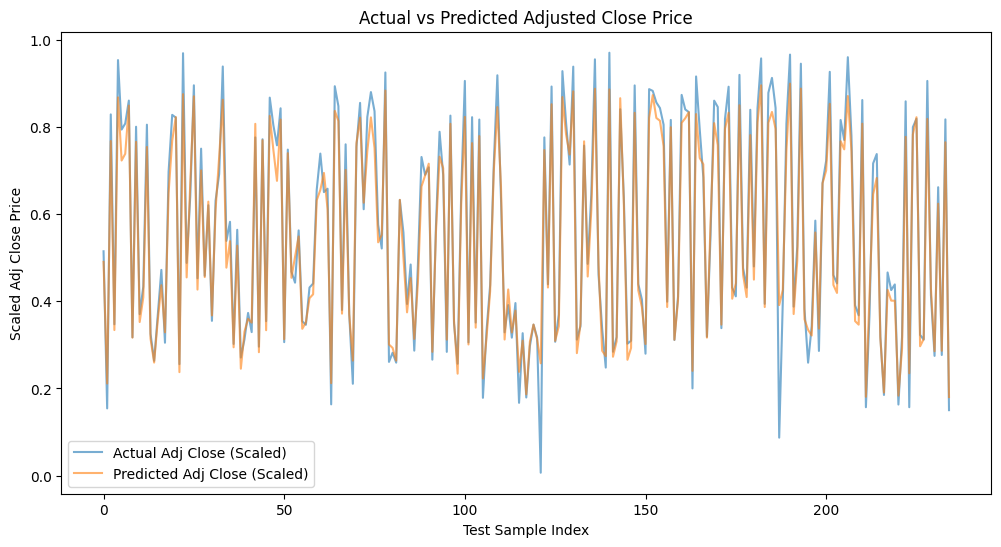

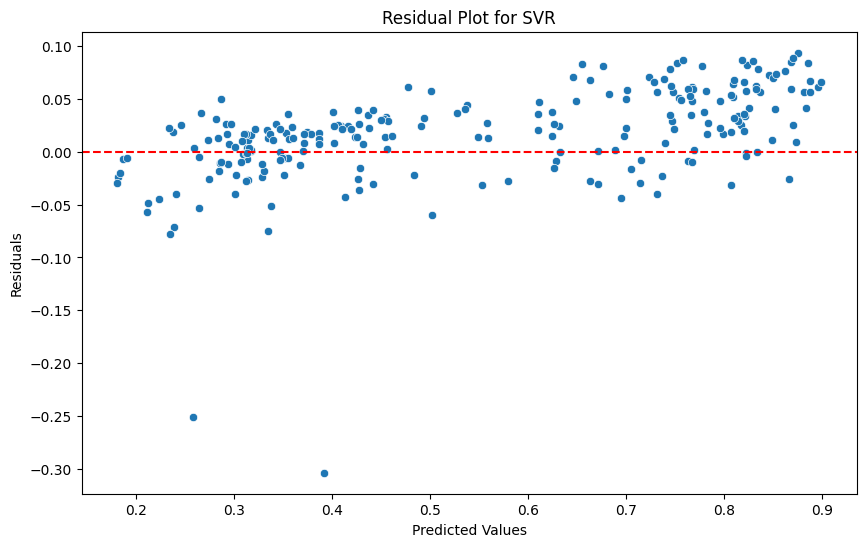

In [19]:

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Adj Close (Scaled)', alpha=0.6)
plt.plot(y_pred, label='Predicted Adj Close (Scaled)', alpha=0.6)
plt.xlabel('Test Sample Index')
plt.ylabel('Scaled Adj Close Price')
plt.title('Actual vs Predicted Adjusted Close Price')
plt.legend()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for SVR')
plt.show()